# 05 Advanced Models

Objective: evaluate XGBoost as the Week 7 advanced Gradient Boosting model for `ClosePrice` prediction while preserving the Week 6 preprocessing, outlier handling, and time-based validation/test design.

This notebook follows the final Week 7 workflow:
- Compare two strong Week 6 feature-set candidates for XGBoost on the May 2026 validation month.
- Fix the selected XGBoost feature set before hyperparameter tuning.
- Run an untuned XGBoost baseline on the selected feature set.
- Tune `max_depth`, `learning_rate`, and `n_estimators` using the May 2026 validation month.
- Run a small boundary check because the initial best tuning result sat on the upper grid boundary.
- Check stability on earlier historical cutoffs.
- Evaluate the final tuned model once on the June 2026 test set.
- Compare against the prior Linear Regression, Decision Tree, and Random Forest results.


## 0. Setup

In [1]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "idx-california-price-prediction",
]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "processed").exists() and (root / "notebooks").exists()
)
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
ENGINEERED_DATA_DIR = PROCESSED_DATA_DIR / "week6_feature_engineering"
ENGINEERED_SPLIT_DIR = ENGINEERED_DATA_DIR / "splits"
SPLIT_PLAN_CSV = PROCESSED_DATA_DIR / "crmls_week3_split_plan.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week7_advanced_models"
MODEL_DIR = PROJECT_ROOT / "models" / "week7_advanced_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ENGINEERED_CSV = ENGINEERED_DATA_DIR / "crmls_week6_engineered.csv"
FINAL_TRAIN_CSV = ENGINEERED_SPLIT_DIR / "final_train_fixed_window_engineered.csv"
TEST_CSV = ENGINEERED_SPLIT_DIR / "test_latest_month_engineered.csv"
MODEL_PATH = MODEL_DIR / "xgboost_tuned_pipeline.joblib"

RANDOM_STATE = 42
TARGET = "ClosePrice"
VALIDATION_MONTH = "2026-05"
FEATURE_SET_NAME = None

required_files = [ENGINEERED_CSV, FINAL_TRAIN_CSV, TEST_CSV, SPLIT_PLAN_CSV]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing required Week 6 files: " + ", ".join(str(path) for path in missing_files))

print(f"Project root: {PROJECT_ROOT}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Week 6 engineered data: {ENGINEERED_CSV}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model path: {MODEL_PATH}")

Project root: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction
XGBoost version: 3.3.0
Week 6 engineered data: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/week6_feature_engineering/crmls_week6_engineered.csv
Output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week7_advanced_models
Model path: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/week7_advanced_models/xgboost_tuned_pipeline.joblib


## 1. Load Data and Candidate Feature Sets

Use the Week 6 engineered dataset and preserve the Week 6 preprocessing pattern: median imputation for numeric fields, missing-category imputation plus one-hot encoding for categorical fields, high-cardinality category grouping, and no numeric scaling for tree-based models.

XGBoost evaluates two Week 6 feature-set candidates before tuning:
- `Base + UnifiedSchoolDistrict`
- `Base + Structural Derived + UnifiedSchoolDistrict`


In [2]:
CATEGORICAL_DTYPE_COLS = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
    "UnifiedSchoolDistrict",
]


def normalize_categorical_dtypes(df):
    for col in CATEGORICAL_DTYPE_COLS:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("__missing__")
    return df


def load_split_file(path):
    df = normalize_categorical_dtypes(pd.read_csv(path, low_memory=False))
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df


def load_engineered_data(path=ENGINEERED_CSV):
    return load_split_file(path)


def available(columns, df):
    return [col for col in columns if col in df.columns]

split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})
historical_plan = (
    split_plan[split_plan["split_type"] == "historical_eval"]
    .copy()
    .sort_values("eval_month")
)
final_plan = split_plan[split_plan["split_type"] == "final_test"].copy().iloc[0]
fixed_train_window_months = int(final_plan["train_window_months"])

engineered_df = load_engineered_data()
final_train_raw = load_split_file(FINAL_TRAIN_CSV)
final_test_raw = load_split_file(TEST_CSV)

print(f"Engineered data shape: {engineered_df.shape}")
print(f"Final train shape: {final_train_raw.shape}")
print(f"Final test shape: {final_test_raw.shape}")
print(f"Historical cutoffs: {historical_plan['eval_month'].astype(str).tolist()}")

Engineered data shape: (333060, 78)
Final train shape: (191942, 77)
Final test shape: (12858, 77)
Historical cutoffs: ['2025-09', '2025-11', '2026-01', '2026-03', '2026-05']


In [3]:
LOCATION_QUALITY_FLAG_COLS = [
    "Latitude_missing",
    "Longitude_missing",
    "invalid_coordinates_flag",
    "PostalCode_format_issue_flag",
]

base_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
    "Flooring_material_count",
]
structural_model_numeric_cols = [
    "PropertyAgeYears",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LogLotToLivingAreaRatio",
]
base_structural_numeric_cols = [col for col in base_numeric_cols if col != "YearBuilt"] + structural_model_numeric_cols

base_boolean_cols = [
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "Flooring_Carpet",
    "Flooring_Tile",
    "Flooring_Wood",
    "Flooring_Laminate",
    "Flooring_Vinyl",
    "Flooring_Stone",
    "Flooring_Concrete",
    "Flooring_Bamboo",
    "Flooring_Brick",
    "Flooring_SeeRemarks",
    "Flooring_multiple_materials_flag",
]
structural_derived_flag_cols = ["HasGarage"]

base_categorical_cols = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
]
school_categorical_cols = ["UnifiedSchoolDistrict"]

base_flag_cols = [
    col for col in engineered_df.columns
    if (col.endswith("_missing") or col == "invalid_coordinates_flag")
    and col not in LOCATION_QUALITY_FLAG_COLS
]

XGBOOST_FEATURE_SET_CANDIDATES = {
    "Base + UnifiedSchoolDistrict": {
        "numeric": base_numeric_cols,
        "categorical": base_categorical_cols + school_categorical_cols,
        "boolean": base_boolean_cols,
        "flag": base_flag_cols,
    },
    "Base + Structural Derived + UnifiedSchoolDistrict": {
        "numeric": base_structural_numeric_cols,
        "categorical": base_categorical_cols + school_categorical_cols,
        "boolean": base_boolean_cols,
        "flag": base_flag_cols + structural_derived_flag_cols,
    },
}


def feature_groups_for_config(feature_config, df):
    numeric_features = available(feature_config["numeric"], df)
    categorical_features = available(feature_config["categorical"], df)
    boolean_features = available(feature_config["boolean"], df)
    flag_features = available(feature_config["flag"], df)
    feature_columns = numeric_features + categorical_features + boolean_features + flag_features
    return numeric_features, categorical_features, boolean_features, flag_features, feature_columns


candidate_feature_summary = []
for feature_set_name, candidate_config in XGBOOST_FEATURE_SET_CANDIDATES.items():
    candidate_numeric_cols, candidate_categorical_cols, candidate_boolean_cols, candidate_flag_cols, candidate_feature_cols = feature_groups_for_config(
        candidate_config,
        engineered_df,
    )
    candidate_feature_summary.append({
        "feature_set": feature_set_name,
        "numeric_features": len(candidate_numeric_cols),
        "categorical_features": len(candidate_categorical_cols),
        "boolean_features": len(candidate_boolean_cols),
        "flag_features": len(candidate_flag_cols),
        "total_raw_features": len(candidate_feature_cols),
    })

candidate_feature_summary_df = pd.DataFrame(candidate_feature_summary)
display(candidate_feature_summary_df)


,feature_set,numeric_features,categorical_features,boolean_features,flag_features,total_raw_features
0,Base + UnifiedSchoolDistrict,12,7,16,15,50
1,Base + Structural Derived + UnifiedSchoolDistrict,15,7,16,16,54


## 2. Validation and Test Design

Use May 2026 as the validation month for feature-set selection and hyperparameter tuning. June 2026 remains untouched until final testing. Historical stability checks use earlier cutoffs only, so they are not part of selecting the final parameter values.


In [4]:
def rows_for_plan(plan_row, source_df):
    train_start = pd.Period(str(plan_row["train_month_start"]), freq="M")
    train_end = pd.Period(str(plan_row["train_month_end"]), freq="M")
    eval_month = pd.Period(str(plan_row["eval_month"]), freq="M")
    train_df = source_df[source_df["close_month"].between(train_start, train_end)].copy()
    eval_df = source_df[source_df["close_month"] == eval_month].copy()
    return train_df, eval_df

validation_plan = historical_plan[historical_plan["eval_month"] == VALIDATION_MONTH].iloc[0]
validation_train_raw, validation_raw = rows_for_plan(validation_plan, engineered_df)

print(f"Validation month: {VALIDATION_MONTH}")
print(f"Validation train months: {validation_plan['train_month_start']} through {validation_plan['train_month_end']}")
print(f"Validation train raw shape: {validation_train_raw.shape}")
print(f"Validation raw shape: {validation_raw.shape}")
print(f"Final train months: {final_plan['train_month_start']} through {final_plan['train_month_end']}")
print(f"Final test month: {final_plan['eval_month']}")

Validation month: 2026-05
Validation train months: 2024-11 through 2026-04
Validation train raw shape: (190598, 78)
Validation raw shape: (12014, 78)
Final train months: 2024-12 through 2026-05
Final test month: 2026-06


## 3. Build XGBoost Pipeline

The pipeline keeps preprocessing inside the model workflow so imputers and encoders are fit only on the training portion of each validation or test split. XGBoost uses `tree_method="hist"` for faster training on the large one-hot encoded tabular dataset.


In [5]:
HIGH_CARDINALITY_CATEGORICAL_COLS = ["City", "PostalCode", "MLSAreaMajor"]
HIGH_CARDINALITY_MIN_FREQUENCY = 20


def make_regular_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_high_cardinality_encoder(min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY):
    if min_frequency is None:
        return make_regular_onehot_encoder()
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse=True,
        )


def split_categorical_features(categorical_features):
    high_cardinality_features = [
        col for col in categorical_features
        if col in HIGH_CARDINALITY_CATEGORICAL_COLS
    ]
    regular_categorical_features = [
        col for col in categorical_features
        if col not in HIGH_CARDINALITY_CATEGORICAL_COLS
    ]
    return high_cardinality_features, regular_categorical_features


def build_preprocessing_pipeline(
    numeric_features,
    categorical_features,
    boolean_features,
    flag_features,
    scale_numeric=False,
    high_cardinality_min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY,
):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    high_cardinality_features, regular_categorical_features = split_categorical_features(categorical_features)

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_features),
            ("high_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_high_cardinality_encoder(high_cardinality_min_frequency)),
            ]), high_cardinality_features),
            ("regular_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_regular_onehot_encoder()),
            ]), regular_categorical_features),
            ("bool", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))]), boolean_features),
            ("flag", Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0))]), flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )


def build_xgboost_pipeline_for_features(
    model_params=None,
    numeric_features=None,
    categorical_features=None,
    boolean_features=None,
    flag_features=None,
):
    if model_params is None:
        model_params = {}

    preprocess = build_preprocessing_pipeline(
        numeric_features=numeric_cols if numeric_features is None else numeric_features,
        categorical_features=categorical_cols if categorical_features is None else categorical_features,
        boolean_features=boolean_cols if boolean_features is None else boolean_features,
        flag_features=flag_cols if flag_features is None else flag_features,
        scale_numeric=False,
        high_cardinality_min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY,
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **model_params,
    )

    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])


def build_xgboost_pipeline(model_params=None):
    return build_xgboost_pipeline_for_features(model_params=model_params)

In [6]:
def apply_train_price_bounds(train_df, eval_df, target_col=TARGET, lower_q=0.005, upper_q=0.995):
    lower_bound = train_df[target_col].quantile(lower_q)
    upper_bound = train_df[target_col].quantile(upper_q)
    train_mask = train_df[target_col].between(lower_bound, upper_bound)
    eval_mask = eval_df[target_col].between(lower_bound, upper_bound)
    return (
        train_df.loc[train_mask].copy(),
        eval_df.loc[eval_mask].copy(),
        {
            "price_lower_bound": lower_bound,
            "price_upper_bound": upper_bound,
            "train_rows_before_outlier_filter": len(train_df),
            "train_rows_after_outlier_filter": int(train_mask.sum()),
            "eval_rows_before_outlier_filter": len(eval_df),
            "eval_rows_after_outlier_filter": int(eval_mask.sum()),
        },
    )


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    absolute_percentage_error = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": absolute_percentage_error.mean(),
        "mdape": absolute_percentage_error.median(),
    }


def clipped_predict(model, X):
    return np.clip(model.predict(X), 0, None)

validation_train_df, validation_df, validation_bound_info = apply_train_price_bounds(
    validation_train_raw,
    validation_raw,
)
final_train_df, final_test_df, final_bound_info = apply_train_price_bounds(
    final_train_raw,
    final_test_raw,
)

print(f"Validation train after price filter: {len(validation_train_df):,} of {len(validation_train_raw):,}")
print(f"Validation rows after price filter: {len(validation_df):,} of {len(validation_raw):,}")
print(f"Final train after price filter: {len(final_train_df):,} of {len(final_train_raw):,}")
print(f"Final test rows after price filter: {len(final_test_df):,} of {len(final_test_raw):,}")

Validation train after price filter: 188,699 of 190,598
Validation rows after price filter: 11,900 of 12,014
Final train after price filter: 190,039 of 191,942
Final test rows after price filter: 12,713 of 12,858


## 4. XGBoost Feature Set Precheck

Before tuning XGBoost hyperparameters, compare the two strongest Week 6 feature-set candidates on the May 2026 validation month using default XGBoost settings. The selected feature set is fixed for all later XGBoost steps.

Result: `Base + Structural Derived + UnifiedSchoolDistrict` was selected because it had slightly better validation R2 (`0.8674` vs. `0.8648`) and MdAPE (`11.83%` vs. `12.15%`) than `Base + UnifiedSchoolDistrict`.


In [7]:
feature_set_precheck_rows = []

for feature_set_name, candidate_config in XGBOOST_FEATURE_SET_CANDIDATES.items():
    candidate_numeric_cols, candidate_categorical_cols, candidate_boolean_cols, candidate_flag_cols, candidate_feature_cols = feature_groups_for_config(
        candidate_config,
        validation_train_df,
    )
    print(f"Feature set precheck: {feature_set_name} ({len(candidate_feature_cols)} raw features)")

    candidate_model = build_xgboost_pipeline_for_features(
        numeric_features=candidate_numeric_cols,
        categorical_features=candidate_categorical_cols,
        boolean_features=candidate_boolean_cols,
        flag_features=candidate_flag_cols,
    )

    start_time = time.perf_counter()
    candidate_model.fit(validation_train_df[candidate_feature_cols], validation_train_df[TARGET])
    fit_seconds = time.perf_counter() - start_time

    train_predictions = clipped_predict(candidate_model, validation_train_df[candidate_feature_cols])
    validation_predictions = clipped_predict(candidate_model, validation_df[candidate_feature_cols])
    train_metrics = regression_metrics(validation_train_df[TARGET], train_predictions)
    validation_metrics = regression_metrics(validation_df[TARGET], validation_predictions)

    feature_set_precheck_rows.append({
        "model": "XGBoost",
        "configuration": "default_feature_set_precheck",
        "validation_month": VALIDATION_MONTH,
        "feature_set": feature_set_name,
        "n_raw_features": len(candidate_feature_cols),
        **validation_bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": validation_metrics["r2"],
        "validation_mae": validation_metrics["mae"],
        "validation_rmse": validation_metrics["rmse"],
        "validation_mape": validation_metrics["mape"],
        "validation_mdape": validation_metrics["mdape"],
    })

feature_set_precheck_df = pd.DataFrame(feature_set_precheck_rows).sort_values(
    ["validation_r2", "validation_mdape"],
    ascending=[False, True],
).reset_index(drop=True)
feature_set_precheck_df["train_validation_r2_gap"] = feature_set_precheck_df["train_r2"] - feature_set_precheck_df["validation_r2"]
feature_set_precheck_df.to_csv(OUTPUT_DIR / "xgboost_feature_set_precheck_results.csv", index=False)
display(feature_set_precheck_df.round(4))

selected_feature_set_row = feature_set_precheck_df.iloc[0]
FEATURE_SET_NAME = selected_feature_set_row["feature_set"]
feature_config = XGBOOST_FEATURE_SET_CANDIDATES[FEATURE_SET_NAME]
numeric_cols, categorical_cols, boolean_cols, flag_cols, feature_cols = feature_groups_for_config(
    feature_config,
    engineered_df,
)

selected_feature_summary = pd.DataFrame([{
    "selected_feature_set": FEATURE_SET_NAME,
    "selection_validation_r2": selected_feature_set_row["validation_r2"],
    "selection_validation_mdape": selected_feature_set_row["validation_mdape"],
    "numeric_features": len(numeric_cols),
    "categorical_features": len(categorical_cols),
    "boolean_features": len(boolean_cols),
    "flag_features": len(flag_cols),
    "total_raw_features": len(feature_cols),
}])
selected_feature_summary.to_csv(OUTPUT_DIR / "xgboost_selected_feature_set.csv", index=False)
display(selected_feature_summary.round(4))
print(feature_cols)

Feature set precheck: Base + UnifiedSchoolDistrict (50 raw features)
Feature set precheck: Base + Structural Derived + UnifiedSchoolDistrict (54 raw features)


,model,configuration,validation_month,feature_set,n_raw_features,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,default_feature_set_precheck,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,54,190000.0,8750000.0,190598,188699,12014,11900,2.9103,0.9019,177553.2121,0.8674,201155.5517,363593.6221,16.1186,11.8310,0.0346
1,XGBoost,default_feature_set_precheck,2026-05,Base + UnifiedSchoolDistrict,50,190000.0,8750000.0,190598,188699,12014,11900,2.9388,0.8992,181819.2298,0.8648,206601.2597,367092.3942,16.6834,12.1452,0.0344


,selected_feature_set,selection_validation_r2,selection_validation_mdape,numeric_features,categorical_features,boolean_features,flag_features,total_raw_features
0,Base + Structural Derived + UnifiedSchoolDistrict,0.8674,11.831,15,7,16,16,54


['LivingArea', 'LotSizeSquareFeet', 'Latitude', 'Longitude', 'AssociationFee', 'BedroomsTotal', 'BathroomsTotalInteger', 'GarageSpaces', 'ParkingTotal', 'Stories', 'Flooring_material_count', 'PropertyAgeYears', 'BedBathRatio', 'LivingAreaPerBedroom', 'LogLotToLivingAreaRatio', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'Levels', 'HighSchoolDistrict', 'UnifiedSchoolDistrict', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN', 'Flooring_Carpet', 'Flooring_Tile', 'Flooring_Wood', 'Flooring_Laminate', 'Flooring_Vinyl', 'Flooring_Stone', 'Flooring_Concrete', 'Flooring_Bamboo', 'Flooring_Brick', 'Flooring_SeeRemarks', 'Flooring_multiple_materials_flag', 'LivingArea_missing', 'LotSizeSquareFeet_missing', 'YearBuilt_missing', 'AssociationFee_missing', 'BedroomsTotal_missing', 'BathroomsTotalInteger_missing', 'GarageSpaces_missing', 'ParkingTotal_missing', 'Stories_missing', 'ViewYN_missing', 'PoolPrivateYN_missing', 'AttachedGarageYN_missing', 'Fire

## 5. Untuned XGBoost

Run the default XGBoost model on the selected feature set so the tuning lift is visible. The untuned model reached validation R2 `0.8674`, MAE `$201,156`, and MdAPE `11.83%`.


In [8]:
X_validation_train = validation_train_df[feature_cols]
y_validation_train = validation_train_df[TARGET]
X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET]

default_xgb = build_xgboost_pipeline()
start_time = time.perf_counter()
default_xgb.fit(X_validation_train, y_validation_train)
default_fit_seconds = time.perf_counter() - start_time

default_train_predictions = clipped_predict(default_xgb, X_validation_train)
default_validation_predictions = clipped_predict(default_xgb, X_validation)
default_train_metrics = regression_metrics(y_validation_train, default_train_predictions)
default_validation_metrics = regression_metrics(y_validation, default_validation_predictions)

default_validation_result = pd.DataFrame([{
    "model": "XGBoost",
    "configuration": "default",
    "validation_month": VALIDATION_MONTH,
    "feature_set": FEATURE_SET_NAME,
    "fit_seconds": default_fit_seconds,
    "train_r2": default_train_metrics["r2"],
    "train_mae": default_train_metrics["mae"],
    "validation_r2": default_validation_metrics["r2"],
    "validation_mae": default_validation_metrics["mae"],
    "validation_rmse": default_validation_metrics["rmse"],
    "validation_mape": default_validation_metrics["mape"],
    "validation_mdape": default_validation_metrics["mdape"],
}])

default_validation_result.to_csv(OUTPUT_DIR / "xgboost_default_validation_results.csv", index=False)
display(default_validation_result.round(4))

,model,configuration,validation_month,feature_set,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape
0,XGBoost,default,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,2.8502,0.9019,177553.2121,0.8674,201155.5517,363593.6221,16.1186,11.831


## 6. Light Hyperparameter Tuning

Tune only the three requested parameters on the May 2026 validation month. R2 is the primary selection metric and MdAPE is the tie-breaker.

The initial 12-configuration grid selected `max_depth=7`, `learning_rate=0.08`, and `n_estimators=800`, with validation R2 `0.8911` and MdAPE `9.42%`.


In [9]:
param_grid = {
    "max_depth": [5, 7, 9, 11],
    "learning_rate": [0.05, 0.08, 0.10],
    "n_estimators": [600, 800, 1000, 1200],
}

print(f"Number of tuning configurations: {len(list(ParameterGrid(param_grid)))}")

Number of tuning configurations: 48


In [ ]:
tuning_results = []

for params in ParameterGrid(param_grid):
    print("Training:", params)
    model = build_xgboost_pipeline(params)

    start_time = time.perf_counter()
    model.fit(X_validation_train, y_validation_train)
    fit_seconds = time.perf_counter() - start_time

    train_predictions = clipped_predict(model, X_validation_train)
    validation_predictions = clipped_predict(model, X_validation)
    train_metrics = regression_metrics(y_validation_train, train_predictions)
    validation_metrics = regression_metrics(y_validation, validation_predictions)

    tuning_results.append({
        "model": "XGBoost",
        "configuration": "tuned_candidate",
        "validation_month": VALIDATION_MONTH,
        "feature_set": FEATURE_SET_NAME,
        **params,
        **validation_bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": validation_metrics["r2"],
        "validation_mae": validation_metrics["mae"],
        "validation_rmse": validation_metrics["rmse"],
        "validation_mape": validation_metrics["mape"],
        "validation_mdape": validation_metrics["mdape"],
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    ["validation_r2", "validation_mdape"],
    ascending=[False, True],
).reset_index(drop=True)
tuning_results_df["train_validation_r2_gap"] = tuning_results_df["train_r2"] - tuning_results_df["validation_r2"]
tuning_results_df.to_csv(OUTPUT_DIR / "xgboost_tuning_results.csv", index=False)

display(tuning_results_df.round(4))

initial_best_row = tuning_results_df.iloc[0]
best_params = {
    "max_depth": int(initial_best_row["max_depth"]),
    "learning_rate": float(initial_best_row["learning_rate"]),
    "n_estimators": int(initial_best_row["n_estimators"]),
}
print("Initial best params:", best_params)

Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 800}
Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1000}
Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1200}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 800}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1200}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 800}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 1000}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 1200}
Training: {'learning_rate': 0.05, 'max_depth': 11, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 11, 'n_estimators': 800

,model,configuration,validation_month,feature_set,learning_rate,max_depth,n_estimators,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.10,7,1200,190000.0,8750000.0,190598,188699,12014,11900,15.0027,0.9567,119419.6201,0.8962,166416.7084,321613.7309,12.6890,8.9142,0.0605
1,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.08,9,1200,190000.0,8750000.0,190598,188699,12014,11900,18.5788,0.9691,102491.2644,0.8962,162440.9877,321739.2291,12.1974,8.4388,0.0730
2,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.08,9,1000,190000.0,8750000.0,190598,188699,12014,11900,18.2541,0.9661,107188.2239,0.8954,163647.7772,322835.8733,12.3278,8.5356,0.0706
3,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.08,11,1200,190000.0,8750000.0,190598,188699,12014,11900,27.8148,0.9816,81217.7616,0.8952,159543.9154,323141.9418,11.8045,7.9351,0.0863
4,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.10,7,1000,190000.0,8750000.0,190598,188699,12014,11900,11.8308,0.9526,124456.5389,0.8952,168224.0301,323264.6984,12.8678,9.0820,0.0575
5,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.08,11,1000,190000.0,8750000.0,190598,188699,12014,11900,26.2896,0.9796,85484.5555,0.8951,160248.8862,323305.6124,11.8772,8.0147,0.0844
6,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.10,9,1200,190000.0,8750000.0,190598,188699,12014,11900,20.6453,0.9726,96691.0905,0.8947,161620.1577,323994.9496,12.0796,8.2861,0.0779
7,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.08,11,800,190000.0,8750000.0,190598,188699,12014,11900,21.2103,0.9771,90535.9074,0.8945,161356.5986,324339.6103,11.9842,8.1086,0.0826
8,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.08,9,800,190000.0,8750000.0,190598,188699,12014,11900,13.6240,0.9623,112649.6878,0.8944,165501.3983,324433.9090,12.5237,8.7691,0.0679
9,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,0.10,9,1000,190000.0,8750000.0,190598,188699,12014,11900,16.7354,0.9693,101779.4214,0.8943,162813.5603,324629.9184,12.1946,8.3812,0.0750


Initial best params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 1200}


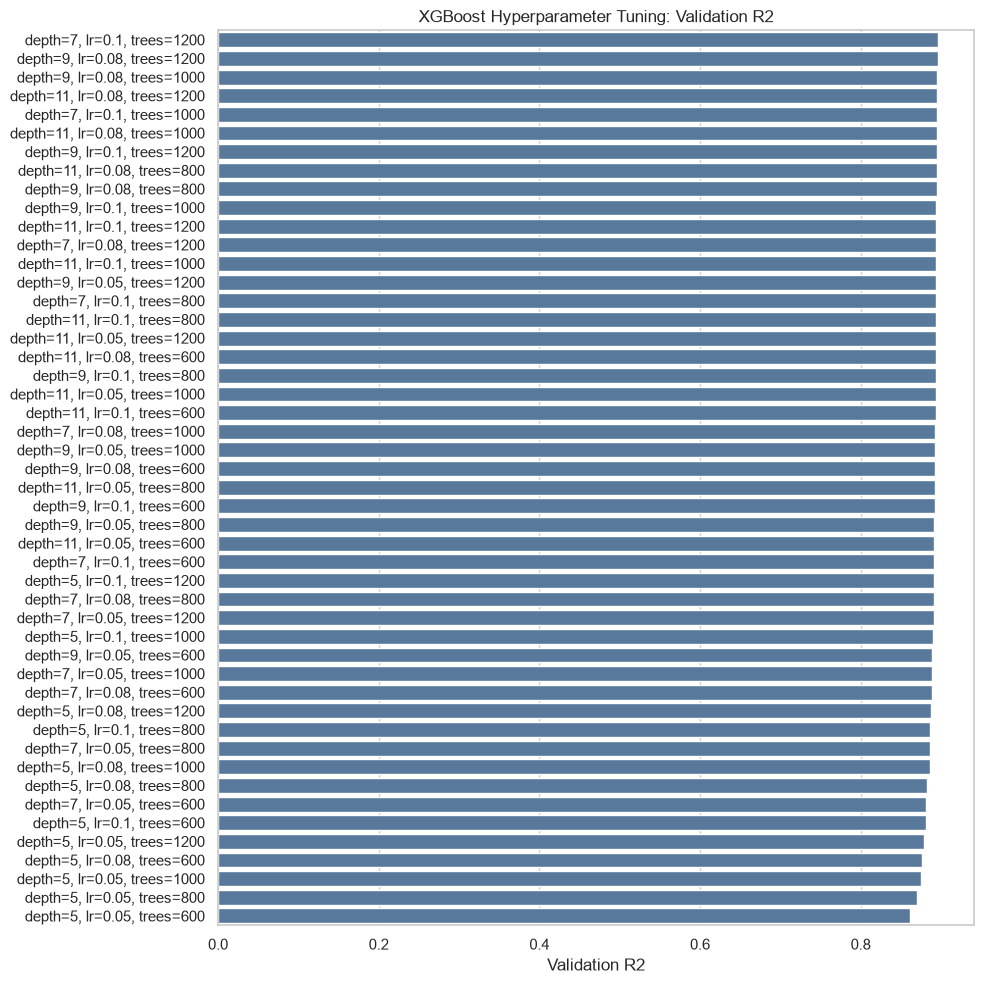

In [13]:
plot_df = tuning_results_df.copy()
plot_df["configuration_label"] = (
    "depth=" + plot_df["max_depth"].astype(str)
    + ", lr=" + plot_df["learning_rate"].astype(str)
    + ", trees=" + plot_df["n_estimators"].astype(str)
)

plt.figure(figsize=(10, 10))
sns.barplot(
    data=plot_df.sort_values("validation_r2", ascending=False),
    x="validation_r2",
    y="configuration_label",
    color="#4c78a8",
)
plt.title("XGBoost Hyperparameter Tuning: Validation R2")
plt.xlabel("Validation R2")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Historical Stability Check

Use the boundary-check-selected parameters on earlier cutoffs. May 2026 is excluded here because it was used for feature-set selection and tuning.

Result: the tuned XGBoost model was stable across the four earlier cutoffs, with mean validation R2 `0.9017`, standard deviation `0.0027`, and mean MdAPE `8.47%`.


In [16]:
stability_months = [
    month for month in historical_plan["eval_month"].astype(str).tolist()
    if month < VALIDATION_MONTH
]


def evaluate_xgboost_fold(eval_month, model_params):
    plan_row = historical_plan[historical_plan["eval_month"] == eval_month].iloc[0]
    train_raw, eval_raw = rows_for_plan(plan_row, engineered_df)
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)

    model = build_xgboost_pipeline(model_params)
    start_time = time.perf_counter()
    model.fit(train_df[feature_cols], train_df[TARGET])
    fit_seconds = time.perf_counter() - start_time

    train_predictions = clipped_predict(model, train_df[feature_cols])
    eval_predictions = clipped_predict(model, eval_df[feature_cols])
    train_metrics = regression_metrics(train_df[TARGET], train_predictions)
    eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)

    return {
        "model": "XGBoost",
        "configuration": "tuned",
        "feature_set": FEATURE_SET_NAME,
        "eval_month": eval_month,
        "train_month_start": plan_row["train_month_start"],
        "train_month_end": plan_row["train_month_end"],
        **model_params,
        **bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": eval_metrics["r2"],
        "validation_mae": eval_metrics["mae"],
        "validation_rmse": eval_metrics["rmse"],
        "validation_mape": eval_metrics["mape"],
        "validation_mdape": eval_metrics["mdape"],
    }

historical_results = pd.DataFrame(
    evaluate_xgboost_fold(eval_month, best_params)
    for eval_month in stability_months
)
historical_results["train_validation_r2_gap"] = historical_results["train_r2"] - historical_results["validation_r2"]
historical_results.to_csv(OUTPUT_DIR / "xgboost_historical_results.csv", index=False)
display(historical_results.round(4))

historical_summary = pd.DataFrame([{
    "model": "XGBoost",
    "configuration": "tuned",
    "feature_set": FEATURE_SET_NAME,
    "n_cutoffs": historical_results["eval_month"].nunique(),
    "mean_validation_r2": historical_results["validation_r2"].mean(),
    "std_validation_r2": historical_results["validation_r2"].std(),
    "min_validation_r2": historical_results["validation_r2"].min(),
    "max_validation_r2": historical_results["validation_r2"].max(),
    "mean_validation_mae": historical_results["validation_mae"].mean(),
    "mean_validation_rmse": historical_results["validation_rmse"].mean(),
    "mean_validation_mape": historical_results["validation_mape"].mean(),
    "mean_validation_mdape": historical_results["validation_mdape"].mean(),
    "mean_train_validation_r2_gap": historical_results["train_validation_r2_gap"].mean(),
}])
historical_summary.to_csv(OUTPUT_DIR / "xgboost_historical_summary.csv", index=False)
display(historical_summary.round(4))

,model,configuration,feature_set,eval_month,train_month_start,train_month_end,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,2025-09,2024-03,2025-08,7,0.1,1200,195000.0,8200000.0,207447,205402,11449,11339,14.9632,0.9571,118523.5120,0.8983,150114.1125,289499.0924,12.7781,8.7504,0.0587
1,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,2025-11,2024-05,2025-10,7,0.1,1200,195000.0,8377990.0,206555,204506,9720,9601,14.0433,0.9567,118439.2492,0.9020,153574.5062,297452.3367,12.7420,8.7344,0.0547
2,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,2026-01,2024-07,2025-12,7,0.1,1200,190000.0,8500000.0,200379,198443,7485,7390,14.2021,0.9566,118133.4361,0.8968,155854.2334,304237.2197,13.2810,8.8444,0.0598
3,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,2026-03,2024-09,2026-02,7,0.1,1200,190000.0,8550000.0,190638,188755,11169,11031,14.9815,0.9572,118135.6330,0.9042,153814.5666,292166.5361,12.4062,8.6449,0.0530


,model,configuration,feature_set,n_cutoffs,mean_validation_r2,std_validation_r2,min_validation_r2,max_validation_r2,mean_validation_mae,mean_validation_rmse,mean_validation_mape,mean_validation_mdape,mean_train_validation_r2_gap
0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,4,0.9003,0.0034,0.8968,0.9042,153339.3547,295838.7962,12.8018,8.7435,0.0566


## 8. Final Test Evaluation

After selecting the feature set and hyperparameters on validation data, train once on the full final training window and evaluate once on the June 2026 test set.

Final selected configuration: `max_depth=9`, `learning_rate=0.08`, `n_estimators=1000`.


In [17]:
final_xgb_model = build_xgboost_pipeline(best_params)
start_time = time.perf_counter()
final_xgb_model.fit(final_train_df[feature_cols], final_train_df[TARGET])
final_fit_seconds = time.perf_counter() - start_time

final_train_predictions = clipped_predict(final_xgb_model, final_train_df[feature_cols])
final_test_predictions = clipped_predict(final_xgb_model, final_test_df[feature_cols])
final_train_metrics = regression_metrics(final_train_df[TARGET], final_train_predictions)
final_test_metrics = regression_metrics(final_test_df[TARGET], final_test_predictions)

final_xgb_result = pd.DataFrame([{
    "model": "XGBoost",
    "configuration": "tuned",
    "target_transform": "raw",
    "feature_set": FEATURE_SET_NAME,
    "train_window_months": fixed_train_window_months,
    "final_train_month_start": final_plan["train_month_start"],
    "final_train_month_end": final_plan["train_month_end"],
    "test_month": final_plan["eval_month"],
    "n_raw_features": len(feature_cols),
    **best_params,
    **final_bound_info,
    "fit_seconds": final_fit_seconds,
    "train_r2": final_train_metrics["r2"],
    "train_mae": final_train_metrics["mae"],
    "test_r2": final_test_metrics["r2"],
    "test_mae": final_test_metrics["mae"],
    "test_rmse": final_test_metrics["rmse"],
    "test_mape": final_test_metrics["mape"],
    "test_mdape": final_test_metrics["mdape"],
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
}])

final_xgb_result.to_csv(OUTPUT_DIR / "xgboost_final_test_results.csv", index=False)
display(final_xgb_result.T)

,0
model,XGBoost
configuration,tuned
target_transform,raw
feature_set,Base + Structural Derived + UnifiedSchoolDistrict
train_window_months,18
final_train_month_start,2024-12
final_train_month_end,2026-05
test_month,2026-06
n_raw_features,54
max_depth,7


## 9. Model Comparison

Compare against existing Week 6 model results. The Week 6 table includes each prior model's selected Week 6 feature set; the `feature_set` column makes feature-set differences explicit.

XGBoost achieved the highest test R2 (`0.8973`) and lower MAE than Random Forest, while Random Forest still had slightly better percentage-error metrics.


In [18]:
week6_results_path = PROJECT_ROOT / "outputs" / "week6_feature_engineering" / "final_base_vs_selected_feature_results.csv"
if not week6_results_path.exists():
    raise FileNotFoundError(f"Missing Week 6 comparison results: {week6_results_path}")

week6_results = pd.read_csv(week6_results_path)
week6_selected_results = week6_results[week6_results["evaluation_role"] == "Selected New"].copy()
week6_selected_results["configuration"] = "week6_selected"
week6_selected_results["target_transform"] = "raw"

comparison_columns = [
    "model",
    "configuration",
    "target_transform",
    "feature_set",
    "test_r2",
    "test_mae",
    "test_rmse",
    "test_mape",
    "test_mdape",
    "train_r2",
]

comparison_df = pd.concat([
    week6_selected_results[comparison_columns],
    final_xgb_result[comparison_columns + ["fit_seconds"]],
], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values("test_r2", ascending=False)
comparison_df.to_csv(OUTPUT_DIR / "xgboost_model_comparison.csv", index=False)
display(comparison_df.round(4))

,model,configuration,target_transform,feature_set,test_r2,test_mae,test_rmse,test_mape,test_mdape,train_r2,fit_seconds
3,XGBoost,tuned,raw,Base + Structural Derived + UnifiedSchoolDistrict,0.8979,163575.7568,315783.7938,12.7020,8.8844,0.9574,14.1405
2,RandomForestRegressor,week6_selected,raw,Base + UnifiedSchoolDistrict,0.8814,165379.8387,340310.2413,12.2006,7.8416,0.9833,NaN
1,LinearRegression,week6_selected,raw,Base + Structural Derived + UnifiedSchoolDistrict,0.8443,225144.6832,389953.3123,20.5232,14.4915,0.8421,NaN
0,DecisionTreeRegressor,week6_selected,raw,Base + UnifiedSchoolDistrict,0.7663,231246.6101,477746.8225,16.8703,10.8808,0.9999,NaN


## 10. Prediction Diagnostics and Feature Importance

Save row-level predictions, inspect actual-vs-predicted behavior, and review XGBoost feature importances. Feature importance is treated as a model diagnostic only, not causal evidence.


In [19]:
test_predictions_df = final_test_df[[
    "ListingKey",
    "CloseDate",
    "close_month",
    "CountyOrParish",
    TARGET,
]].copy()
test_predictions_df["model"] = "XGBoost"
test_predictions_df["configuration"] = "tuned"
test_predictions_df["feature_set"] = FEATURE_SET_NAME
test_predictions_df["predicted_ClosePrice"] = final_test_predictions
test_predictions_df["residual"] = test_predictions_df[TARGET] - test_predictions_df["predicted_ClosePrice"]
test_predictions_df["absolute_error"] = test_predictions_df["residual"].abs()
test_predictions_df["absolute_percentage_error"] = test_predictions_df["absolute_error"] / test_predictions_df[TARGET] * 100

test_predictions_df.to_csv(OUTPUT_DIR / "test_predictions_xgboost.csv", index=False)
display(test_predictions_df.head())

,ListingKey,CloseDate,close_month,CountyOrParish,ClosePrice,model,configuration,feature_set,predicted_ClosePrice,residual,absolute_error,absolute_percentage_error
0,1014091927,2026-06-26,2026-06,San Luis Obispo,3000000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,1.020090e+06,1.979910e+06,1.979910e+06,65.996998
1,1035814040,2026-06-11,2026-06,Alameda,595000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,1.058180e+06,-4.631799e+05,4.631799e+05,77.845357
2,1076159305,2026-06-22,2026-06,Tuolumne,280000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,6.082474e+05,-3.282474e+05,3.282474e+05,117.231228
3,1076795790,2026-06-25,2026-06,San Bernardino,865000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,7.328348e+05,1.321652e+05,1.321652e+05,15.279212
6,1082181091,2026-06-15,2026-06,San Diego,1675835.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,1.296806e+06,3.790294e+05,3.790294e+05,22.617344


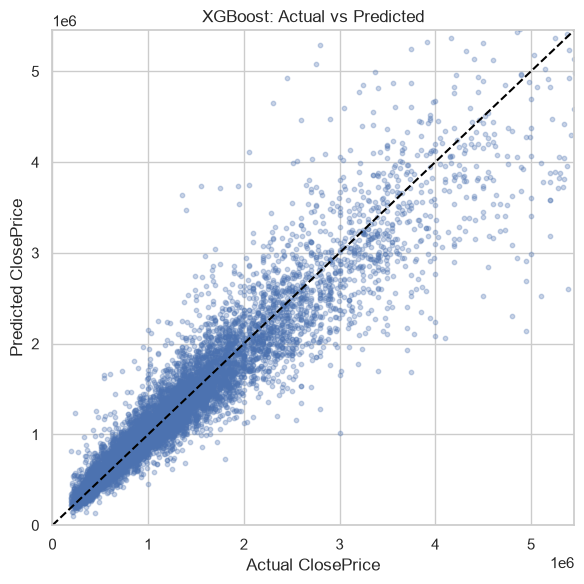

In [20]:
plt.figure(figsize=(6, 6))
max_price = np.nanpercentile(final_test_df[TARGET], 99)
plt.scatter(final_test_df[TARGET], final_test_predictions, s=10, alpha=0.3)
plt.plot([0, max_price], [0, max_price], linestyle="--", color="black")
plt.xlim(0, max_price)
plt.ylim(0, max_price)
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

,feature,importance
2221,regular_cat__CountyOrParish_Riverside,0.040014
2225,regular_cat__CountyOrParish_San Diego,0.035946
2224,regular_cat__CountyOrParish_San Bernardino,0.033951
2875,regular_cat__UnifiedSchoolDistrict_Newport-Mes...,0.031646
2505,regular_cat__HighSchoolDistrict_Newport Mesa U...,0.028053
2217,regular_cat__CountyOrParish_Orange,0.022950
2942,regular_cat__UnifiedSchoolDistrict_Santa Barba...,0.019109
2439,regular_cat__HighSchoolDistrict_Laguna Beach U...,0.017029
2231,regular_cat__CountyOrParish_Santa Clara,0.016967
2469,regular_cat__HighSchoolDistrict_Manhattan Unified,0.016412


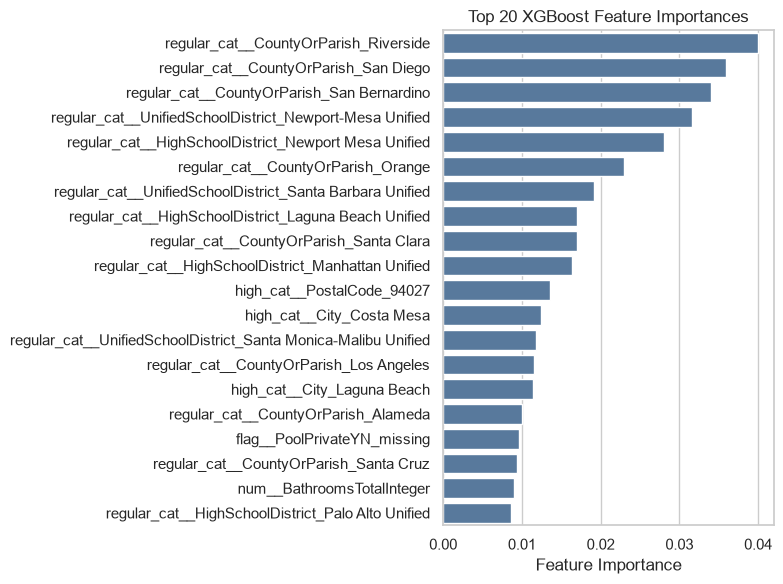

In [21]:
preprocessor = final_xgb_model.named_steps["preprocess"]
xgb_estimator = final_xgb_model.named_steps["model"]

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{idx}" for idx in range(len(xgb_estimator.feature_importances_))])

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_estimator.feature_importances_,
    })
    .sort_values("importance", ascending=False)
)
importance_df.to_csv(OUTPUT_DIR / "xgboost_feature_importances.csv", index=False)
display(importance_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(20), x="importance", y="feature", color="#4c78a8")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [22]:
joblib.dump(
    {
        "model": final_xgb_model,
        "feature_set": FEATURE_SET_NAME,
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "boolean_cols": boolean_cols,
        "flag_cols": flag_cols,
        "target": TARGET,
        "target_transform": "raw",
        "best_params": best_params,
        "price_bounds": {
            "lower": final_bound_info["price_lower_bound"],
            "upper": final_bound_info["price_upper_bound"],
        },
        "validation_month": VALIDATION_MONTH,
        "test_month": str(final_plan["eval_month"]),
        "xgboost_version": xgb.__version__,
    },
    MODEL_PATH,
)

print("Saved model:", MODEL_PATH)

Saved model: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/week7_advanced_models/xgboost_tuned_pipeline.joblib


## 11. Summary

- Compared two XGBoost feature-set candidates on the May 2026 validation month before hyperparameter tuning.
- XGBoost selected `Base + Structural Derived + UnifiedSchoolDistrict` with 54 raw features. This feature set slightly outperformed `Base + UnifiedSchoolDistrict` on validation R2 (`0.8674` vs. `0.8648`) and MdAPE (`11.83%` vs. `12.15%`).
- Used May 2026 as the validation month and kept June 2026 untouched as the final test month.
- The default XGBoost model on the selected feature set reached validation R2 `0.8674`, MAE `$201,156`, and MdAPE `11.83%`.
- Initial 12-configuration tuning selected:
  - `max_depth = 7`
  - `learning_rate = 0.08`
  - `n_estimators = 800`
  - Validation R2 = `0.8911`
  - Validation MAE = `$173,311`
  - Validation MdAPE = `9.42%`
- Because the initial best was on the grid boundary, an 8-configuration boundary check was run. The best boundary configuration was:
  - `max_depth = 9`
  - `learning_rate = 0.08`
  - `n_estimators = 1000`
  - Validation R2 = `0.8954`
  - Validation MAE = `$163,648`
  - Validation MdAPE = `8.54%`
- The boundary check improved validation R2 by `0.0043` versus the initial grid best, but the train-validation R2 gap increased from `0.0522` to `0.0706`, so the stronger model also shows more overfitting risk.
- Historical stability across the four earlier cutoffs was strong with mean validation R2 `0.9017`, standard deviation `0.0027`, and mean MdAPE `8.47%`.
- Final June 2026 test metrics for the selected XGBoost model:
  - Test R2 = `0.8973`
  - Test MAE = `$160,875`
  - Test RMSE = `$316,742`
  - Test MAPE = `12.31%`
  - Test MdAPE = `8.51%`
- Compared with Week 6 selected models, XGBoost had the highest final test R2: `0.8973` vs. Random Forest `0.8814`, Linear Regression `0.8443`, and Decision Tree `0.7663`.
- XGBoost also improved MAE versus Random Forest (`$160,875` vs. `$165,380`), but Random Forest still had better percentage-error metrics: MdAPE `7.84%` vs. XGBoost `8.51%`, and MAPE `12.20%` vs. XGBoost `12.31%`.
- Final train R2 was `0.9664` versus test R2 `0.8973`, indicating meaningful model complexity and some overfitting risk, though final test performance still improved overall.
- Top feature importances were mostly location-related, especially unified school district, high school district, and county indicators. These importances are model diagnostics, not causal evidence.
